K-S test

Kolmogorov-Smirnov

# Test de Kolmogorov-Smirnov (K-S)

> **Fuente principal**: *Numerical Recipes in C: The Art of Scientific Computing*, Capítulo 14, Sección 14.3 "Are Two Distributions Different?" [1]

---

## 1. Introducción conceptual

El test de Kolmogorov-Smirnov es una prueba **no paramétrica** diseñada para comparar distribuciones de probabilidad. Su gran ventaja radica en que:

- **No requiere binning**: Trabaja directamente con datos no agrupados, evitando la pérdida de información que implica la discretización en histogramas.
- **Es invariante bajo reparametrización**: Si transformas la variable $x \mapsto g(x)$ con $g$ monótona, el valor del estadístico $D$ no cambia. Esto significa que obtienes el mismo resultado usando $x$ o $\log x$, por ejemplo.
- **Es sensible a diferencias en la forma global** de la distribución, no solo en momentos específicos como media o varianza.

---

## 2. Fundamentos teóricos

### 2.1 Función de distribución acumulada empírica

Dada una muestra de $N$ observaciones independientes $\{x_1, x_2, \ldots, x_N\}$, definimos el **estimador empírico de la función de distribución acumulada (FDA)** como:

$$
S_N(x) = \frac{1}{N} \sum_{i=1}^{N} \mathbb{I}(x_i \leq x)
$$

donde $\mathbb{I}(\cdot)$ es la función indicadora que vale 1 si la condición se cumple y 0 en caso contrario. Geométricamente, $S_N(x)$ es una función escalonada que aumenta en $1/N$ cada vez que cruzamos un punto de datos.

### 2.2 El estadístico de Kolmogorov-Smirnov

El corazón del test es medir la **máxima discrepancia vertical** entre dos funciones de distribución acumulada.

#### Caso 1: Una muestra vs. un modelo teórico

Si comparamos nuestra muestra contra una distribución teórica con FDA conocida $P(x)$, el estadístico K-S se define como:

$$
D = \max_{-\infty < x < \infty} \left| S_N(x) - P(x) \right| \tag{14.3.5}
$$

#### Caso 2: Dos muestras independientes

Si disponemos de dos conjuntos de datos con tamaños $N_1$ y $N_2$, y sus respectivas FDAs empíricas $S_{N_1}(x)$ y $S_{N_2}(x)$, entonces:

$$
D = \max_{-\infty < x < \infty} \left| S_{N_1}(x) - S_{N_2}(x) \right| \tag{14.3.6}
$$

> **Interpretación**: $D$ representa la mayor distancia vertical entre las dos curvas acumulativas. Un valor grande de $D$ sugiere que las distribuciones subyacentes son diferentes.

---

## 3. Distribución del estadístico bajo la hipótesis nula

Bajo la **hipótesis nula** $H_0$: *"ambas muestras provienen de la misma distribución"*, la distribución del estadístico $D$ puede aproximarse analíticamente.

### 3.1 Función de probabilidad $Q_{\text{KS}}(\lambda)$

La probabilidad de observar un valor del estadístico mayor que un umbral se calcula mediante la serie:

$$
Q_{\text{KS}}(\lambda) = 2 \sum_{j=1}^{\infty} (-1)^{j-1} e^{-2 j^2 \lambda^2} \tag{14.3.7}
$$

Esta función es monótona decreciente con:
- $Q_{\text{KS}}(0) = 1$
- $Q_{\text{KS}}(\infty) = 0$

### 3.2 Aproximación práctica para el valor-p

Para una muestra de tamaño $N$, el **nivel de significancia aproximado** (valor-p) asociado a un valor observado $D$ es:

$$
\text{Prob}(D > D_{\text{obs}}) \approx Q_{\text{KS}}\!\left( \left[ \sqrt{N} + 0.12 + \frac{0.11}{\sqrt{N}} \right] D_{\text{obs}} \right) \tag{14.3.9}
$$

Para el caso de **dos muestras** de tamaños $N_1$ y $N_2$, se reemplaza $\sqrt{N}$ por el tamaño efectivo:

$$
N_e = \frac{N_1 N_2}{N_1 + N_2}
$$

---

## 4. Implementación práctica (pseudocódigo)

A continuación, se presenta un esquema simplificado del algoritmo para el caso de una muestra:

```
Función ksone(datos[1..N], func_teórica(x)):
    1. Ordenar datos en forma ascendente → datos_ord
    2. Inicializar D = 0, fo = 0
    3. Para j = 1 hasta N:
        fn = j / N                          # FDA empírica en el punto j
        ff = func_teórica(datos_ord[j])     # FDA teórica en el mismo punto
        dt = max(|fo - ff|, |fn - ff|)      # Máxima discrepancia local
        D = max(D, dt)                      # Actualizar máximo global
        fo = fn                             # Avanzar FDA empírica
    4. Calcular en = sqrt(N)
    5. prob = probks((en + 0.12 + 0.11/en) * D)
    6. Retornar (D, prob)
```

> La rutina `probks` evalúa la serie $Q_{\text{KS}}(\lambda)$ truncando cuando los términos son suficientemente pequeños (ver *Numerical Recipes*, p. 626) [1].

---

## 5. Propiedades y limitaciones

### Ventajas
| Propiedad | Implicación práctica |
|-----------|---------------------|
| **No paramétrico** | No asume forma específica de la distribución (normal, exponencial, etc.) |
| **Invariante ante transformaciones monótonas** | Resultados consistentes bajo cambios de escala o variable |
| **Sensible a diferencias globales** | Detecta desplazamientos, cambios de forma y asimetrías |

### Limitaciones
| Limitación | Explicación |
|------------|-------------|
| **Menor sensibilidad en las colas** | La varianza de $|S_N(x) - P(x)|$ es proporcional a $P(x)[1-P(x)]$, máxima en $P=0.5$ y mínima en las colas [1] |
| **No detecta "notchas" estrechas** | Una distribución con un hueco muy estrecho puede pasar el test si pocos datos caen en esa región |
| **Requiere datos continuos** | Para datos discretos o con muchos empates, se necesitan correcciones o tests alternativos |

---

## 6. Variantes del estadístico K-S

Para mejorar la sensibilidad en regiones específicas, se han propuesto estadísticos modificados:

### 6.1 Estadístico de Anderson-Darling (estabilizado)

$$
D^* = \max_{-\infty < x < \infty} \frac{\left| S_N(x) - P(x) \right|}{\sqrt{P(x)[1 - P(x)]}} \tag{14.3.11}
$$

Este peso inverso a la desviación estándar teórica incrementa la sensibilidad en las colas de la distribución.

### 6.2 Estadístico de Kuiper

$$
V = \max_x \left[ S_N(x) - P(x) \right] - \min_x \left[ S_N(x) - P(x) \right]
$$

Kuiper's statistic es invariante bajo rotaciones en el círculo (útil para datos angulares o cíclicos) y tiene sensibilidad uniforme en todo el dominio [1].

---

## 7. Extensión bidimensional

Para distribuciones en $\mathbb{R}^2$, Fasano y Franceschini [1] propusieron una generalización del test K-S:

1. Para cada punto $(x_i, y_i)$ de los datos, se definen **cuatro cuadrantes** centrados en ese punto.
2. Se cuenta la fracción de puntos en cada cuadrante para ambas distribuciones.
3. El estadístico $D$ es la máxima diferencia absoluta entre estas fracciones, promediada sobre todos los puntos y cuadrantes.

La significancia aproximada se calcula como:

$$
\text{Prob}(D > D_{\text{obs}}) \approx Q_{\text{KS}}\!\left( \frac{\sqrt{N} \, D_{\text{obs}}}{1 + \sqrt{1 - r^2} \left(0.25 - \frac{0.75}{\sqrt{N}}\right)} \right) \tag{14.7.1}
$$

donde $r$ es el coeficiente de correlación lineal entre las variables.

> **Nota**: Esta aproximación es válida para $N \gtrsim 20$ y valores-p menores a ~0.20 [1].

---

## 8. Referencias

[1] Press, W. H., Teukolsky, S. A., Vetterling, W. T., & Flannery, B. P. (1992). *Numerical Recipes in C: The Art of Scientific Computing* (2nd ed.). Cambridge University Press. Capítulo 14: "Statistical Description of Data", Secciones 14.3 y 14.7.

[2] Kolmogorov, A. N. (1933). Sulla determinazione empirica di una legge di distribuzione. *Giornale dell'Istituto Italiano degli Attuari*, 4, 83–91.

[3] Smirnov, N. V. (1948). Table for estimating the goodness of fit of empirical distributions. *Annals of Mathematical Statistics*, 19(2), 279–281.

---

> **Consejo práctico**: Al interpretar resultados del test K-S, recuerda que un valor-p pequeño ($< 0.05$) indica evidencia contra la hipótesis nula, pero **no prueba** que las distribuciones sean diferentes de manera absoluta. Siempre complementa el análisis con gráficos de las FDAs y, si es posible, con tests adicionales sensibles a aspectos específicos de interés.

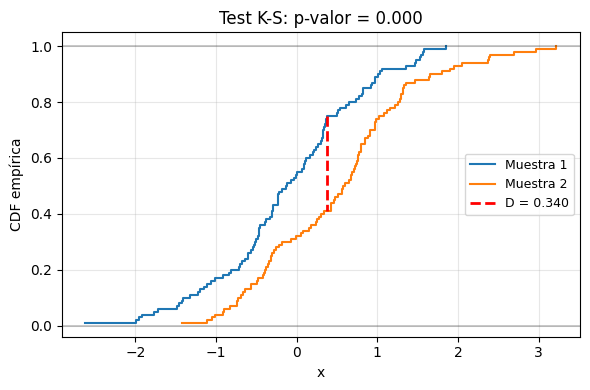

Estadístico D: 0.3400
p-valor: 0.0000
Rechazar H0 (α=0.05): True


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
n = 100

# Generar muestras: normal vs normal desplazada
sample1 = np.random.normal(loc=0, scale=1, size=n)
sample2 = np.random.normal(loc=0.5, scale=1, size=n)

# Calcular estadístico K-S
D, p_value = stats.ks_2samp(sample1, sample2)

# Ordenar muestras para CDF empírica
x1 = np.sort(sample1)
x2 = np.sort(sample2)
y1 = np.arange(1, n+1) / n
y2 = np.arange(1, n+1) / n

# Encontrar punto de máxima discrepancia
all_x = np.concatenate([x1, x2])
all_x = np.sort(np.unique(all_x))
cdf1 = np.searchsorted(x1, all_x, side='right') / n
cdf2 = np.searchsorted(x2, all_x, side='right') / n
diff = np.abs(cdf1 - cdf2)
idx_max = np.argmax(diff)
x_D = all_x[idx_max]
y1_D, y2_D = cdf1[idx_max], cdf2[idx_max]

# Gráfico
fig, ax = plt.subplots(figsize=(6, 4))
ax.step(x1, y1, where='post', label='Muestra 1', linewidth=1.5)
ax.step(x2, y2, where='post', label='Muestra 2', linewidth=1.5)
ax.plot([x_D, x_D], [y1_D, y2_D], 'r--', linewidth=2, label=f'D = {D:.3f}')
ax.axhline(y=0, color='k', linewidth=0.3)
ax.axhline(y=1, color='k', linewidth=0.3)
ax.set_xlabel('x')
ax.set_ylabel('CDF empírica')
ax.set_title(f'Test K-S: p-valor = {p_value:.3f}')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Estadístico D: {D:.4f}")
print(f"p-valor: {p_value:.4f}")
print(f"Rechazar H0 (α=0.05): {p_value < 0.05}")

q-q plot

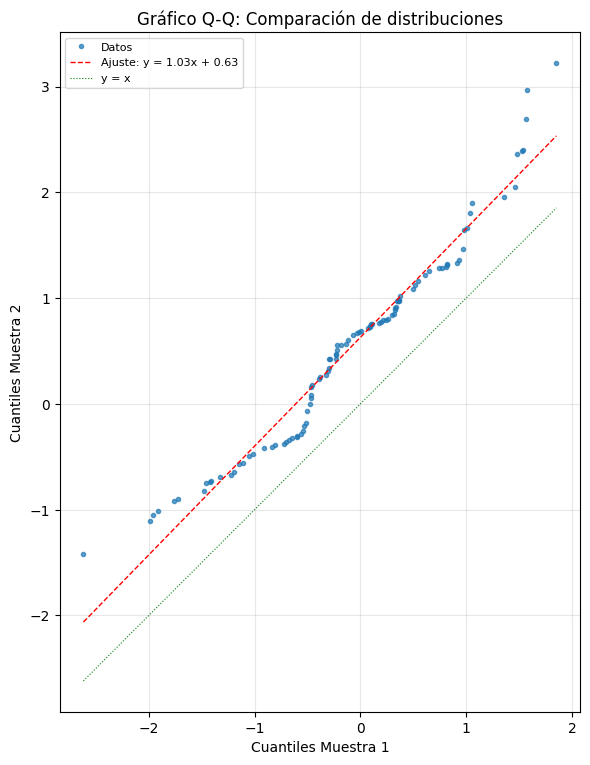

Correlación entre cuantiles: 0.9790
Pendiente del ajuste: 1.0280
Intercepto del ajuste: 0.6291

Interpretación:
  - Pendiente ≈ 1: escalas similares
  - Intercepto ≠ 0: desplazamiento en locación
  - Desviaciones de la línea: diferencias en forma


In [5]:
# Probabilidades empíricas (método de Blom)
p = (np.arange(1, n+1) - 0.375) / (n + 0.25)

# Cuantiles teóricos de la distribución normal estándar
z = stats.norm.ppf(p)

# Gráfico Q-Q: muestra 1 vs muestra 2
fig, ax = plt.subplots(figsize=(6, 4*2))
ax.plot(x1, x2, 'o', markersize=3, alpha=0.7, label='Datos')

# Línea de referencia: ajuste lineal por mínimos cuadrados
slope, intercept, r_value, _, _ = stats.linregress(x1, x2)
x_line = np.array([x1.min(), x1.max()])
ax.plot(x_line, intercept + slope * x_line, 'r--', linewidth=1, 
        label=f'Ajuste: y = {slope:.2f}x + {intercept:.2f}')

# Línea y = x para referencia visual
ax.plot(x_line, x_line, 'g:', linewidth=0.8, label='y = x')

ax.set_xlabel('Cuantiles Muestra 1')
ax.set_ylabel('Cuantiles Muestra 2')
ax.set_title('Gráfico Q-Q: Comparación de distribuciones')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_aspect('equal', 'box')
plt.tight_layout()
plt.show()

# Estadísticos resumidos
print(f"Correlación entre cuantiles: {r_value:.4f}")
print(f"Pendiente del ajuste: {slope:.4f}")
print(f"Intercepto del ajuste: {intercept:.4f}")
print(f"\nInterpretación:")
print(f"  - Pendiente ≈ 1: escalas similares")
print(f"  - Intercepto ≠ 0: desplazamiento en locación")
print(f"  - Desviaciones de la línea: diferencias en forma")

# Inferencia Bayesiana

# Inferencia Bayesiana: Teoría Analítica y Ejemplos Aplicados

## 1. Fundamentos Teóricos
La inferencia bayesiana se fundamenta en una interpretación particular del teorema de Bayes, donde la evidencia observacional se utiliza para actualizar cuantitativamente el grado de creencia sobre un modelo o un conjunto de parámetros $\theta$. A diferencia del enfoque frecuentista, que considera a los parámetros como valores fijos pero desconocidos, la estadística bayesiana los modela como variables aleatorias gobernadas por distribuciones de probabilidad.

### 1.1 Teorema de Bayes para Inferencia
Sea $X$ el conjunto de datos observables y $\theta$ el vector de parámetros del modelo. El teorema de Bayes establece que la distribución posterior de los parámetros, condicionada a los datos, es proporcional al producto de la distribución a priori y la función de verosimilitud:
$$
P(\theta | X) = \frac{P(\theta) L(X | \theta)}{\int P(u) L(X | u) du}
$$
donde:
- $P(\theta | X)$ es la **distribución posterior**: probabilidad actualizada de $\theta$ tras observar $X$.
- $P(\theta)$ es la **distribución a priori**: información externa o creencia sobre $\theta$ antes de la observación.
- $L(X | \theta) = P(X | \theta)$ es la **función de verosimilitud**: probabilidad de los datos dado un valor específico de $\theta$.
- El denominador $\int P(u) L(X | u) du$ es la **evidencia marginal**, una constante de normalización que garantiza que la posterior sea una densidad de probabilidad válida.

Para un espacio discreto de modelos $M_1, \dots, M_k$, la formulación equivalente es:
$$
P(M_i(\theta) | X) = \frac{P(X | M_i(\theta)) P(M_i(\theta))}{\sum_{j} P(X | M_j(\theta)) P(M_j(\theta))}
$$

### 1.2 Propiedades Analíticas Fundamentales
- **Actualización secuencial**: La posterior obtenida con un conjunto de datos puede utilizarse rigurosamente como priori para un nuevo conjunto de observaciones.
- **Intervalos creíbles**: A diferencia de los intervalos de confianza, un intervalo creíble al $100(1-\alpha)\%$ permite afirmar directamente que $P(\hat{\theta}_B - k_1 \leq \theta \leq \hat{\theta}_B + k_2 | X) = 0.95$.
- **Estimadores bayesianos**:
  - \textit{Máxima a posteriori} (MAP): corresponde al modo de la distribución posterior y maximiza $P(\theta | X)$.
  - \textit{Media posterior}: $\hat{\theta}_B = E(\theta | X)$, que minimiza el error cuadrático medio posterior:
  $$
  E[(\theta - \hat{\theta}_B)^2 | X] = \min_a E[(\theta - a)^2 | X]
  $$
  La varianza posterior $E[(\theta - E(\theta|X))^2 | X]$ proporciona una medida natural de incertidumbre.

## 2. Ejemplo Resuelto 1: Inferencia para una Proporción Binomial
**Problema**: Un astrónomo examina una muestra de núcleos galácticos activos (AGN) para estimar la fracción $\theta$ de AGN que emiten en radio (radio-loud). La información previa indica que solo el 10\% de los AGN son radio-loud. El telescopio tiene una sensibilidad del 80\% para detectar AGN radio-loud ($P(X=1|\theta_1)=0.8$), pero un 30\% de los AGN radio-quiet muestran detecciones espurias ($P(X=1|\theta_2)=0.3$). Si se obtiene una detección positiva ($X=1$), ¿cuál es la probabilidad actualizada de que el AGN sea realmente radio-loud?

**Solución paso a paso**:
1. **Definición de la priori**: $P(\theta=\theta_1) = 0.1$ y $P(\theta=\theta_2) = 0.9$.
2. **Verosimilitades**: $P(X=1|\theta_1) = 0.8$, $P(X=1|\theta_2) = 0.3$.
3. **Aplicación del teorema de Bayes**:
$$
P(\theta=\theta_1 | X=1) = \frac{P(X=1|\theta_1)P(\theta=\theta_1)}{P(X=1|\theta_1)P(\theta=\theta_1) + P(X=1|\theta_2)P(\theta=\theta_2)}
$$
$$
P(\theta=\theta_1 | X=1) = \frac{0.8 \times 0.1}{0.8 \times 0.1 + 0.3 \times 0.9} = \frac{0.08}{0.08 + 0.27} = \frac{0.08}{0.35} \approx 0.23
$$
**Interpretación**: La evidencia positiva eleva la probabilidad de que el AGN sea radio-loud del 10\% al 23\%. Este cálculo ilustra cómo la inferencia bayesiana pondera automáticamente la calidad del instrumento contra la información previa. Si la tasa de falsos positivos se redujera a 0.05, la probabilidad posterior alcanzaría el 95\%, demostrando la dependencia analítica del resultado en la modelización de $P(X|\theta)$.

## 3. Ejemplo Resuelto 2: Inferencia para una Media Gaussiana
**Problema**: Se obtienen $n$ mediciones independientes $X_1, \dots, X_n$ de una variable con distribución normal $N(\mu, \sigma^2)$. Se asume que la varianza $\sigma^2$ es conocida. La información previa sobre la media $\mu$ se modela como una distribución normal $N(\mu_0, \tau^2)$. Se requiere derivar la distribución posterior de $\mu$ y su estimador.

**Solución paso a paso**:
1. **Verosimilitud** (agrupando términos que dependen de $\mu$):
$$
L(X; \mu, \sigma^2) \propto \exp\left[ -\frac{n}{2\sigma^2}(\bar{X}_n - \mu)^2 \right]
$$
2. **Priori**: $\pi(\mu) \propto \exp\left[ -\frac{1}{2\tau^2}(\mu - \mu_0)^2 \right]$.
3. **Posterior** (el producto de dos exponentes cuadráticos genera otra normal):
$$
P(\mu | X) \propto \exp\left\{ -\frac{1}{\gamma^2}(\mu - \hat{\mu})^2 \right\}
$$
Donde la varianza posterior $\gamma^2$ y la media posterior $\hat{\mu}$ se obtienen completando cuadrados:
$$
\gamma^2 = \left( \frac{1}{\tau^2} + \frac{n}{\sigma^2} \right)^{-1} = \frac{\sigma^2}{n} \frac{\tau^2}{\tau^2 + \sigma^2/n}
$$
$$
\hat{\mu} = \gamma^2 \left( \frac{\mu_0}{\tau^2} + \frac{n\bar{X}_n}{\sigma^2} \right) = \left( \frac{\gamma^2}{\tau^2} \right)\mu_0 + \left( 1 - \frac{\gamma^2}{\tau^2} \right)\bar{X}_n
$$
**Interpretación analítica**:
- La posterior es $N(\hat{\mu}, \gamma^2)$.
- $\hat{\mu}$ es una \textit{combinación convexa} de la media muestral $\bar{X}_n$ (estimador de máxima verosimilitud) y la media a priori $\mu_0$.
- Los pesos reflejan la precisión relativa: si $\tau \to \infty$ (priori vaga), $\hat{\mu} \to \bar{X}_n$ y $\gamma^2 \to \sigma^2/n$, recuperando los límites frecuentistas.
- El intervalo creíble al 95\% es $\hat{\mu} \pm 1.96\gamma$.

## 4. Comparación de Hipótesis y Factor de Bayes
Para evaluar $H_0: \theta \in \Theta_0$ frente a $H_1: \theta \in \Theta_1$, el enfoque bayesiano calcula las probabilidades posteriores de cada hipótesis mediante el \textbf{Factor de Bayes} ($BF_{01}$), que cuantifica cuánta más probabilidad otorgan los datos a $H_0$ respecto a $H_1$:
$$
BF_{01} = \frac{P(\Theta_0 | x)}{P(\Theta_1 | x)} \bigg/ \frac{P(\Theta_0)}{P(\Theta_1)} = \frac{\int_{\Theta_0} f(x|\theta)g_0(\theta) d\theta}{\int_{\Theta_1} f(x|\theta)g_1(\theta) d\theta}
$$
donde $g_0$ y $g_1$ son las densidades a priori restringidas a cada subespacio de parámetros.
- Las \textit{odds posteriores} se actualizan multiplicando las odds a priori por el factor de Bayes:
$$
\frac{P(\Theta_0|x)}{P(\Theta_1|x)} = \left( \frac{\pi_0}{1-\pi_0} \right) BF_{01}
$$
- Si $BF_{01} > 1$, la evidencia favorece $H_0$; si $BF_{01} < 1$, favorece $H_1$.
- A diferencia de las pruebas clásicas, este marco trata ambas hipótesis de forma simétrica y proporciona una probabilidad directa para cada una, eliminando la asimetría inherente al valor $p$ y a la decisión binaria de \textit{rechazar/no rechazar}.

## 5. Consideraciones Prácticas y Limitaciones
- **Priors conjugadas**: Se eligen distribuciones a priori que mantengan la forma funcional de la posterior (e.g., Beta para Binomial, Normal para Normal con varianza conocida). Esto facilita el cálculo analítico directo.
- **Priors no informativas**: Cuando se carece de información previa, se emplean distribuciones uniformes o la priori de Jeffreys ($P(\mu, \sigma^2) \propto 1/\sigma^2$), que en muchos casos reproducen resultados frecuentistas asintóticos.
- **Complejidad computacional**: En modelos multidimensionales o con verosimilitudes complejas, la integral de normalización es intratable. Se recurre a métodos de simulación como \textit{Markov Chain Monte Carlo} (MCMC), muestreo de Gibbs o el algoritmo Metropolis-Hastings para generar muestras directamente de $P(\theta | X)$ sin calcular la evidencia marginal.
- **Robustez muestral**: En muestras pequeñas, la inferencia puede ser sensible a la elección de la priori. Sin embargo, conforme $n \to \infty$, la verosimilitud domina y los estimadores bayesianos y frecuentistas convergen, garantizando consistencia asintótica.

# Ejemplo de Inferencia Bayesiana: Radio-loudness en Núcleos Galácticos Activos (AGN)

## Sección: Problema 1

### Enunciado del Problema

Un astrónomo tiene una muestra de núcleos galácticos activos (AGN) seleccionados ópticamente y realiza un sondeo con un radiotelescopio para estimar la fracción de AGN que producen emisión de radio no térmica proveniente de un chorro relativista. 

Se conoce la siguiente información:

1. **Información previa**: Basado en sondeos anteriores, se espera que la prevalencia de AGN radio-loud en la población sea aproximadamente del 10%.

2. **Sensibilidad del instrumento**: El radiotelescopio es suficientemente sensible para medir la emisión de radio el 80% de las veces en AGN que son verdaderamente radio-loud. Los fallos se deben a AGN a muy alto redshift.

3. **Contaminación**: La muestra incluye algunos AGN a bajo redshift donde el telescopio puede detectar emisión de radio térmica proveniente de formación estelar en la galaxia huésped. Esta detección positiva irrelevante ocurre aproximadamente el 30% de las veces en AGN que son radio-quiet.

**Pregunta**: Si se obtiene una detección positiva de radio en un AGN de la muestra, ¿cuál es la probabilidad de que el AGN sea verdaderamente radio-loud? Es decir, calcular $P(\theta = \text{radio-loud} | X = \text{detección positiva})$.

---

### Solución

#### Paso 1: Definir el espacio de hipótesis y los eventos observables

Definimos las siguientes variables:

| Símbolo | Significado |
|---------|-------------|
| $\theta_1$ | El AGN es verdaderamente radio-loud (produce emisión no térmica de chorro) |
| $\theta_2$ | El AGN es radio-quiet (no produce emisión de chorro) |
| $X = 1$ | Se obtiene una detección positiva de radio en el sondeo |
| $X = 0$ | No se detecta emisión de radio |

#### Paso 2: Especificar las probabilidades previas

Basado en estudios anteriores, asignamos la distribución previa:

$$P(\theta = \theta_1) = 0.10 \quad \text{(prior para radio-loud)}$$
$$P(\theta = \theta_2) = 0.90 \quad \text{(prior para radio-quiet)}$$

*Referencia: Sección 3.8.2 del libro, sobre distribuciones previas y el uso de información externa para construir priors informativos.*

#### Paso 3: Especificar la función de verosimilitud

La verosimilitud representa la probabilidad de observar los datos dado cada hipótesis:

- **Sensibilidad (verdaderos positivos)**: 
  $$P(X = 1 | \theta_1) = 0.80$$
  
- **Falsos negativos**:
  $$P(X = 0 | \theta_1) = 1 - 0.80 = 0.20$$

- **Tasa de falsos positivos** (contaminación por emisión térmica):
  $$P(X = 1 | \theta_2) = 0.30$$
  
- **Verdaderos negativos**:
  $$P(X = 0 | \theta_2) = 1 - 0.30 = 0.70$$

*Referencia: Sección 3.8.1, donde se introduce la interpretación de $P(X|\theta)$ como la función de verosimilitud.*

#### Paso 4: Aplicar el Teorema de Bayes

El teorema de Bayes establece:

$$P(\theta_i | X) = \frac{P(X | \theta_i) \cdot P(\theta_i)}{\sum_{j} P(X | \theta_j) \cdot P(\theta_j)}$$

Para nuestro caso, queremos calcular $P(\theta_1 | X = 1)$:

**Numerador** (para $\theta_1$):
$$P(X = 1 | \theta_1) \cdot P(\theta_1) = 0.80 \times 0.10 = 0.08$$

**Denominador** (evidencia marginal):
$$\begin{aligned}
P(X = 1) &= P(X = 1 | \theta_1) \cdot P(\theta_1) + P(X = 1 | \theta_2) \cdot P(\theta_2) \\
&= (0.80 \times 0.10) + (0.30 \times 0.90) \\
&= 0.08 + 0.27 = 0.35
\end{aligned}$$

**Probabilidad posterior**:
$$P(\theta_1 | X = 1) = \frac{0.08}{0.35} = 0.2286 \approx 23\%$$

#### Paso 5: Interpretación de resultados

El resultado indica que, **a pesar de obtener una detección positiva de radio**, solo hay aproximadamente un **23% de probabilidad** de que el AGN sea verdaderamente radio-loud. 

Esto se debe a dos factores:
1. La baja prevalencia previa de AGN radio-loud (solo 10% de la población).
2. La alta tasa de falsos positivos (30%) debido a contaminación por emisión térmica de formación estelar.

**Análisis de sensibilidad al prior**: Si hubiéramos asumido un prior del 20% para radio-loud en lugar del 10%, el cálculo sería:

$$P(\theta_1 | X = 1) = \frac{0.80 \times 0.20}{(0.80 \times 0.20) + (0.30 \times 0.80)} = \frac{0.16}{0.16 + 0.24} = 0.40$$

La probabilidad posterior aumentaría al 40%, mostrando que el resultado es moderadamente sensible a la elección del prior.

**Mejora con datos auxiliares**: Si pudiéramos reducir la tasa de falsos positivos del 30% al 5% mediante datos auxiliares (por ejemplo, índice espectral de radio o polarización), entonces:

$$P(\theta_1 | X = 1) = \frac{0.80 \times 0.10}{(0.80 \times 0.10) + (0.05 \times 0.90)} = \frac{0.08}{0.08 + 0.045} = 0.64$$

¡La probabilidad de descubrimiento verdadero aumentaría al 64%!

*Referencia: Sección 3.8.1 del libro, Ejemplo 3.1, donde se discute este mismo escenario y se enfatiza la importancia de reducir la contaminación para mejorar la inferencia.*

Probabilidad posterior de AGN radio-loud dado detección positiva:
P(theta_1 | X=1) = 0.229 (22.9%)



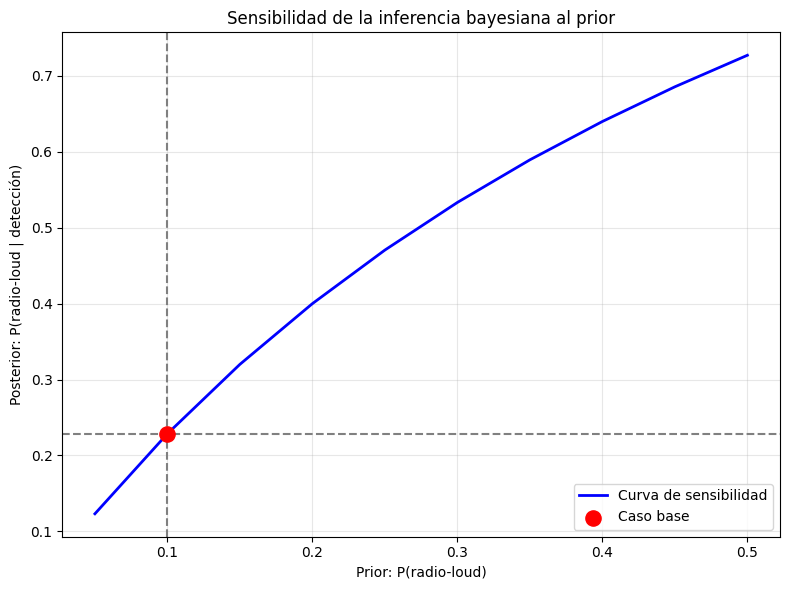

Con tasa de falsos positivos reducida al 5%:
P(theta_1 | X=1) = 0.640 (64.0%)


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Inferencia bayesiana para AGN radio-loudness
# Basado en el Ejemplo 3.1 de Feigelson & Babu (2012)

# Parámetros del problema
prior_radio_loud = 0.10          # P(theta_1): prevalencia previa
sensitivity = 0.80               # P(X=1 | theta_1): sensibilidad
false_positive_rate = 0.30       # P(X=1 | theta_2): tasa de falsos positivos

# Calcular probabilidad posterior P(theta_1 | X=1)
numerador = sensitivity * prior_radio_loud
denominador = numerador + false_positive_rate * (1 - prior_radio_loud)
posterior = numerador / denominador

print("Probabilidad posterior de AGN radio-loud dado detección positiva:")
print(f"P(theta_1 | X=1) = {posterior:.3f} ({posterior*100:.1f}%)\n")

# Análisis de sensibilidad: variar el prior
priors = np.arange(0.05, 0.501, 0.05)
posteriors = (sensitivity * priors) / (sensitivity * priors + false_positive_rate * (1 - priors))

# Graficar sensibilidad
plt.figure(figsize=(8, 6))
plt.plot(priors, posteriors, linewidth=2, color="blue", label="Curva de sensibilidad")
plt.axhline(posterior, linestyle="--", color="gray")
plt.axvline(prior_radio_loud, linestyle="--", color="gray")
plt.scatter(prior_radio_loud, posterior, color="red", s=120, zorder=5, label="Caso base")
plt.xlabel("Prior: P(radio-loud)")
plt.ylabel("Posterior: P(radio-loud | detección)")
plt.title("Sensibilidad de la inferencia bayesiana al prior")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Escenario mejorado: reducir falsos positivos al 5%
false_positive_improved = 0.05
den_improved = numerador + false_positive_improved * (1 - prior_radio_loud)
posterior_improved = numerador / den_improved

print(f"Con tasa de falsos positivos reducida al 5%:")
print(f"P(theta_1 | X=1) = {posterior_improved:.3f} ({posterior_improved*100:.1f}%)")

### Conclusiones

1. **La inferencia bayesiana permite incorporar información previa** (prevalencia de AGN radio-loud) junto con las características del instrumento (sensibilidad y tasa de falsos positivos) para obtener una estimación probabilística del estado verdadero del objeto.

2. **El resultado depende críticamente de la calidad de los datos auxiliares**: reducir la contaminación por falsos positivos tiene un impacto mayor en la probabilidad posterior que aumentar ligeramente el prior.

3. **La interpretación es directa**: en lugar de un valor puntual, obtenemos una distribución de probabilidad que cuantifica nuestra incertidumbre después de observar los datos.

4. **Este enfoque es generalizable**: el mismo marco bayesiano puede extenderse a problemas más complejos, como estimación de parámetros continuos, modelos jerárquicos, o selección de modelos mediante factores de Bayes (Secciones 3.8.4–3.8.6).

*Referencias principales*:
- Feigelson, E. D. & Babu, G. J. (2012). *Modern Statistical Methods for Astronomy with R Applications*. Cambridge University Press. Sección 3.8: "Bayesian statistical inference", pp. 63-72.
- Gregory, P. C. (2005). *Bayesian Logical Data Analysis for the Physical Sciences*. Cambridge University Press.

# Problema: Detección Bayesiana de Exoplanetas por el Método de Tránsito

## Enunciado del problema

Usted es un astrónomo que trabaja con datos del telescopio espacial *TESS* (Transiting Exoplanet Survey Satellite). Su objetivo es determinar si una estrella de tipo solar presenta evidencia estadística de albergar un exoplaneta en órbita, basándose en mediciones fotométricas de su brillo.

Se sabe que:
- La probabilidad *a priori* de que una estrella de tipo solar tenga un exoplaneta en la zona habitable es $P(\text{Planeta}) = 0.15$.
- Cuando *sí* hay un planeta que transita, la probabilidad de detectar una disminución de brillo característica (señal de tránsito) es $P(\text{Señal} \mid \text{Planeta}) = 0.85$.
- Cuando *no* hay planeta, la probabilidad de observar una fluctuación que *parezca* una señal de tránsito (falso positivo, por manchas estelares, ruido instrumental, etc.) es $P(\text{Señal} \mid \neg\text{Planeta}) = 0.08$.

Adicionalmente, si hay un planeta, la profundidad del tránsito $\delta$ (fracción de luz bloqueada) sigue una distribución normal con media $\mu_\delta = 0.01$ (1\%) y desviación estándar $\sigma_\delta = 0.002$. Si no hay planeta, las fluctuaciones de brillo siguen una normal con media 0 y desviación $\sigma_{\text{ruido}} = 0.005$.

## Ítems a resolver

1. **Probabilidad posterior básica:** Suponga que usted observa una señal de tránsito clara en la curva de luz de la estrella. Calcule la probabilidad posterior $P(\text{Planeta} \mid \text{Señal})$ usando el teorema de Bayes. Muestre todos los pasos del cálculo.
2. **Incorporación de datos cuantitativos:** Ahora suponga que, además de detectar la señal, usted mide una profundidad de tránsito de $\delta_{\text{obs}} = 0.0095$. Calcule la probabilidad posterior actualizada $P(\text{Planeta} \mid \delta_{\text{obs}})$, considerando las distribuciones de $\delta$ bajo ambas hipótesis. *Sugerencia: Use la forma continua del teorema de Bayes: $P(H \mid D) \propto P(D \mid H) \cdot P(H)$.*
3. **Distribución posterior del parámetro $\delta$:** Asumiendo que *sí* hay un planeta, derive la distribución posterior para la profundidad real del tránsito $\delta$, dada la observación $\delta_{\text{obs}} = 0.0095$. Asuma una distribución previa uniforme para $\delta$ en el intervalo $[0.005, 0.015]$. Exprese la posterior en forma analítica.
4. **Aplicación en Python:** Escriba un script en Python que:
   - a) Simule 10,000 curvas de luz sintéticas: la mitad con planetas (señal gaussiana con $\delta \sim \mathcal{N}(0.01, 0.002^2)$) y la mitad sin planetas (solo ruido $\mathcal{N}(0, 0.005^2)$).
   - b) Para cada curva simulada, calcule la "evidencia" como la profundidad medida del mínimo.
   - c) Use muestreo por rechazo o MCMC simple para estimar la distribución posterior de $\delta$ dado $\delta_{\text{obs}} = 0.0095$, bajo la hipótesis de que hay planeta.
   - d) Grafique la distribución posterior estimada y compare con la solución analítica del ítem 3.
   *Nota: Use solo bibliotecas estándar como `numpy`, `scipy` y `matplotlib`. No use paquetes de inferencia bayesiana como `pymc3` para este ejercicio.*
5. **Comparación de modelos:** Calcule el factor de Bayes $B_{10} = \frac{P(\delta_{\text{obs}} \mid \text{Planeta})}{P(\delta_{\text{obs}} \mid \neg\text{Planeta})}$ para $\delta_{\text{obs}} = 0.0095$. Interprete el resultado usando la escala de Jeffreys: $B_{10} < 1$ (evidencia contra planeta), $1-3$ (débil), $3-10$ (moderada), $10-30$ (fuerte), $>30$ (muy fuerte).
6. **Reflexión crítica:** Discuta brevemente:
   - a) ¿Cómo cambiarían sus conclusiones si la probabilidad previa $P(\text{Planeta})$ fuera mucho menor (ej. 0.01, para estrellas de tipo diferente)?
   - b) ¿Qué limitaciones tiene el modelo presentado? Mencione al menos dos fuentes de incertidumbre no consideradas (ej. correlación temporal del ruido, múltiples planetas, etc.).

## Entregables esperados

- Soluciones analíticas detalladas para los ítems 1, 2, 3 y 5.
- Código Python comentado para el ítem 4, con gráficos que incluyan etiquetas, leyenda y título descriptivo.
- Respuestas breves pero fundamentadas para el ítem 6.
- Todas las expresiones matemáticas deben escribirse usando notación LaTeX con los símbolos `$` o `$$` según corresponda.

## Pistas y referencias

- Teorema de Bayes para variables continuas: 
  $$P(\theta \mid D) = \frac{P(D \mid \theta) \cdot P(\theta)}{\int P(D \mid \theta') P(\theta') d\theta'}$$
- Para el ítem 4, considere usar `numpy.random.normal` para generar datos y `scipy.stats.norm` para evaluar densidades.
- Consulte la Sección 3.8 del libro *Modern Statistical Methods for Astronomy* (Feigelson & Babu, 2012) para fundamentos de inferencia bayesiana aplicada a problemas astronómicos.

# Explicación de la fórmula de inferencia bayesiana

La ecuación que presentas es la forma continua del **teorema de Bayes** aplicada a la inferencia estadística. Describe matemáticamente cómo se actualiza el conocimiento sobre los parámetros de un modelo $M(\theta)$ una vez que se observan los datos $X$.

A continuación, se desglosa cada componente y su significado estadístico:

## 1. Lado izquierdo: $f(M(\theta)|X)$ (Distribución a posteriori)
* **Qué es:** Es la densidad de probabilidad de los parámetros $\theta$ del modelo $M$, condicionada a los datos observados $X$.
* **Significado:** Representa nuestra creencia actualizada sobre cuáles son los valores más plausibles de los parámetros después de incorporar la evidencia empírica. Es el objetivo central de cualquier análisis bayesiano.

## 2. Numerador: $L(X|M(\theta)) \cdot f(M(\theta))$
Combina los dos pilares de la inferencia:
* **$L(X|M(\theta))$ (Verosimilitud o *likelihood*):** Evalúa qué tan probable es observar el conjunto de datos $X$ bajo la hipótesis de que el modelo posee unos parámetros específicos $\theta$. No es una distribución de probabilidad sobre $\theta$, sino una función de ajuste modelo-datos.
* **$f(M(\theta))$ (Distribución a priori):** Codifica la información externa, conocimientos teóricos o suposiciones iniciales sobre los parámetros $\theta$ *antes* de observar los datos actuales. Puede ser informativa (basada en sondeos previos) o de referencia/no informativa.

## 3. Denominador: $\int L(X|M(\theta')) f(M(\theta')) \, d\theta'$ (Evidencia marginal)
* **Qué es:** Una integral que recorre todo el espacio posible de parámetros $\theta'$.
* **Función principal:** Actúa como **constante de normalización**. Garantiza que la distribución a posteriori integre exactamente a 1, cumpliendo así con los axiomas de probabilidad.
* **Importancia adicional:** Este término es fundamental para la **comparación de modelos** mediante el Factor de Bayes. Cuantifica la probabilidad marginal de los datos bajo un modelo dado, promediando sobre todos los valores posibles de sus parámetros.

## Intuición global del proceso
La fórmula encapsula el ciclo de aprendizaje estadístico bayesiano:
1. Partimos de una creencia inicial (previa).
2. Observamos datos y calculamos qué tan compatibles son con cada valor posible de los parámetros (verosimilitud).
3. Combinamos ambos para obtener una creencia actualizada (posterior).
4. El denominador ajusta matemáticamente el resultado para que sea una distribución válida y permite evaluar la calidad global del modelo frente a otros.

## Nota sobre la notación
En tu expresión original hay un pequeño desajuste en los paréntesis del denominador. La forma matemáticamente precisa es:

$$f(M(\theta)|X) = \frac{L(X|M(\theta)) \cdot f(M(\theta))}{\int L(X|M(\theta')) \cdot f(M(\theta')) \, d\theta'}$$

La notación $M(\theta)$ simplemente enfatiza que estamos trabajando con un modelo estadístico parametrizado, pero es completamente equivalente a la forma compacta $P(\theta|X)$ que se utiliza habitualmente en la literatura.

## Referencia bibliográfica
Esta formulación corresponde directamente a la **Sección 3.8** del libro *Modern Statistical Methods for Astronomy* de Feigelson & Babu (2012), específicamente a la ecuación 3.58 y a la discusión sobre la interpretación de la verosimilitud, la distribución previa y la evidencia marginal en contextos astroestadísticos.